# Campus Wall Decoration — ConvNeXt-Tiny Baseline



In [1]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from PIL import Image

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [6]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

SPLITS_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset"
RAW_IMAGES_FOLDER = "/content/drive/MyDrive/Wall decoration images"
OUTPUT_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results/ConvNeXt-Tiny"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# "tiny" | "small" | "base" | "large" -- bigger = closer to the ConvNeXt-L result in your
# related-work paper, but slower/more memory. Start with tiny, scale up if it helps.
CONVNEXT_VARIANT = "tiny"

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LR = 1e-4

TASKS = {"wall_type": "multiclass", "indoor": "binary"}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ============================================================
# 3. LOAD SPLITS + RESOLVE PATHS
# ============================================================

def load_split(name):
    path = os.path.join(SPLITS_FOLDER, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}\nCheck SPLITS_FOLDER in the CONFIG cell.")
    df = pd.read_csv(path, encoding="utf-8-sig")
    keep = ["image_id", "wall_type", "indoor", "description_en", "description_bn", "color_idea", "group_id"]
    return df[[c for c in keep if c in df.columns]].copy()

EXTENSIONS = [".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG", ".webp", ".WEBP"]

def resolve_image_path(image_id):
    for ext in EXTENSIONS:
        candidate = os.path.join(RAW_IMAGES_FOLDER, image_id + ext)
        if os.path.exists(candidate):
            return candidate
    matches = glob.glob(os.path.join(RAW_IMAGES_FOLDER, image_id + ".*"))
    return matches[0] if matches else None

def attach_image_paths(df):
    df = df.copy()
    df["image_path"] = df["image_id"].apply(resolve_image_path)
    missing = df[df["image_path"].isna()]
    if len(missing) > 0:
        print(f"⚠️  {len(missing)} images not found, dropped: {missing['image_id'].tolist()}")
    return df[df["image_path"].notna()].reset_index(drop=True)

train_df = attach_image_paths(load_split("train.csv"))
val_df   = attach_image_paths(load_split("validation.csv"))
test_df  = attach_image_paths(load_split("test.csv"))

for d in (train_df, val_df, test_df):
    d["indoor"] = pd.to_numeric(d["indoor"], errors="coerce").astype(int)

train_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print("Train pool:", len(train_pool_df), "| Test (held out):", len(test_df))

wall_type_encoder = LabelEncoder().fit(train_pool_df["wall_type"])
for d in (train_pool_df, test_df):
    d["wall_type_label"] = wall_type_encoder.transform(d["wall_type"])

WALL_TYPE_CLASSES = list(wall_type_encoder.classes_)
NUM_CLASSES = {"wall_type": len(WALL_TYPE_CLASSES), "indoor": 2}
TARGET_COLUMN = {"wall_type": "wall_type_label", "indoor": "indoor"}
print("wall_type classes:", WALL_TYPE_CLASSES)


Train pool: 264 | Test (held out): 24
wall_type classes: ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']


In [8]:
# ============================================================
# 4. DATASET + TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class WallDecorationDataset(Dataset):
    def __init__(self, dataframe, target_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row[self.target_column])


## Naive baseline

In [9]:
# ============================================================
# 5. NAIVE MAJORITY-CLASS BASELINE
# ============================================================

results = []

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    majority_class = train_pool_df[target_column].mode()[0]
    y_true = test_df[target_column].values
    y_pred = np.full_like(y_true, fill_value=majority_class)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results.append({"task": task, "method": "naive_majority", "accuracy": acc, "macro_f1": f1_macro})
    print(f"[naive] {task:10s} test acc={acc:.3f} macro_f1={f1_macro:.3f}")


[naive] wall_type  test acc=0.458 macro_f1=0.126
[naive] indoor     test acc=0.792 macro_f1=0.442


## Baseline 1 — ConvNeXt-Tiny frozen-feature + classical classifiers



In [10]:
# ============================================================
# 6. CONVNEXT FEATURE EXTRACTOR
# ============================================================

CONVNEXT_BUILDERS = {
    "tiny":  (models.convnext_tiny,  models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1),
    "small": (models.convnext_small, models.ConvNeXt_Small_Weights.IMAGENET1K_V1),
    "base":  (models.convnext_base,  models.ConvNeXt_Base_Weights.IMAGENET1K_V1),
    "large": (models.convnext_large, models.ConvNeXt_Large_Weights.IMAGENET1K_V1),
}

def get_convnext_feature_extractor(variant):
    builder, weights = CONVNEXT_BUILDERS[variant]
    model = builder(weights=weights)
    feature_dim = model.classifier[2].in_features
    model.classifier[2] = nn.Identity()
    return model.to(DEVICE).eval(), feature_dim


@torch.no_grad()
def extract_features(backbone_model, dataframe, target_column, batch_size=16):
    dataset = WallDecorationDataset(dataframe, target_column, transform=eval_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    all_features, all_labels = [], []
    for images, labels in loader:
        feats = backbone_model(images.to(DEVICE))
        all_features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)


convnext_extractor, feature_dim = get_convnext_feature_extractor(CONVNEXT_VARIANT)
print(f"ConvNeXt-{CONVNEXT_VARIANT} pooled feature dim:", feature_dim)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 167MB/s] 


ConvNeXt-tiny pooled feature dim: 768


In [11]:
# ============================================================
# 7. EXTRACT FEATURES + FIT CLASSICAL CLASSIFIERS
# ============================================================

def get_classical_classifiers():
    return {
        "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
        "linear_svm": SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_SEED),
        "knn": KNeighborsClassifier(n_neighbors=5),
    }

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    X_train, y_train = extract_features(convnext_extractor, train_pool_df, target_column, BATCH_SIZE)
    X_test,  y_test  = extract_features(convnext_extractor, test_df,       target_column, BATCH_SIZE)
    print(f"\n{task}: train features {X_train.shape}, test features {X_test.shape}")

    for clf_name, clf in get_classical_classifiers().items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
        results.append({"task": task, "method": f"frozen_convnext_{CONVNEXT_VARIANT}_{clf_name}",
                         "accuracy": acc, "macro_f1": f1_macro})
        print(f"  [frozen+{clf_name:10s}] acc={acc:.3f} macro_f1={f1_macro:.3f}")



wall_type: train features (264, 768), test features (24, 768)
  [frozen+logreg    ] acc=0.583 macro_f1=0.438
  [frozen+linear_svm] acc=0.500 macro_f1=0.373
  [frozen+knn       ] acc=0.667 macro_f1=0.528

indoor: train features (264, 768), test features (24, 768)
  [frozen+logreg    ] acc=0.958 macro_f1=0.932
  [frozen+linear_svm] acc=0.917 macro_f1=0.850
  [frozen+knn       ] acc=0.833 macro_f1=0.619


## Baseline 2 — ConvNeXt-Tiny fine-tuned end-to-end




In [12]:
# ============================================================
# 8. FINE-TUNE CONVNEXT
# ============================================================

def build_convnext_classifier(variant, num_classes):
    builder, weights = CONVNEXT_BUILDERS[variant]
    model = builder(weights=weights)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model


def compute_class_weights(df, target_column, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=df[target_column].values)
    return torch.tensor(weights, dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), acc, f1_macro


def finetune_convnext(task):
    target_column = TARGET_COLUMN[task]
    num_classes = NUM_CLASSES[task]

    train_ds = WallDecorationDataset(train_pool_df, target_column, transform=train_transform)
    test_ds  = WallDecorationDataset(test_df,       target_column, transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = build_convnext_classifier(CONVNEXT_VARIANT, num_classes).to(DEVICE)
    class_weights = compute_class_weights(train_pool_df, target_column, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=FINE_TUNE_LR)

    for epoch in range(1, FINE_TUNE_EPOCHS + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        print(f"  [{task}] epoch {epoch:02d}/{FINE_TUNE_EPOCHS} "
              f"loss={train_loss:.3f} acc={train_acc:.3f} macro_f1={train_f1:.3f}")

    test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion, optimizer=None)
    print(f"  -> TEST acc={test_acc:.3f} macro_f1={test_f1:.3f}")

    torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, f"finetuned_convnext_{CONVNEXT_VARIANT}_{task}.pt"))
    return model, test_acc, test_f1


finetuned_models = {}
for task in TASKS:
    print(f"\n=== Fine-tuning ConvNeXt-{CONVNEXT_VARIANT} on {task} ===")
    model, test_acc, test_f1 = finetune_convnext(task)
    finetuned_models[task] = model
    results.append({"task": task, "method": f"finetuned_convnext_{CONVNEXT_VARIANT}",
                     "accuracy": test_acc, "macro_f1": test_f1})


import json as json_lib
model_info = {
    "variant": CONVNEXT_VARIANT,
    "wall_type_classes": WALL_TYPE_CLASSES,
    "num_classes": {"wall_type": NUM_CLASSES["wall_type"], "indoor": NUM_CLASSES["indoor"]},
}
with open(os.path.join(OUTPUT_FOLDER, "convnext_model_info.json"), "w") as f:
    json_lib.dump(model_info, f, indent=2)
print(f"\nSaved model info (wall_type class order) -> {os.path.join(OUTPUT_FOLDER, 'convnext_model_info.json')}")




=== Fine-tuning ConvNeXt-tiny on wall_type ===
  [wall_type] epoch 01/20 loss=1.398 acc=0.451 macro_f1=0.396
  [wall_type] epoch 02/20 loss=0.648 acc=0.788 macro_f1=0.813
  [wall_type] epoch 03/20 loss=0.363 acc=0.905 macro_f1=0.918
  [wall_type] epoch 04/20 loss=0.195 acc=0.962 macro_f1=0.971
  [wall_type] epoch 05/20 loss=0.117 acc=0.989 macro_f1=0.993
  [wall_type] epoch 06/20 loss=0.086 acc=0.992 macro_f1=0.995
  [wall_type] epoch 07/20 loss=0.054 acc=0.996 macro_f1=0.995
  [wall_type] epoch 08/20 loss=0.039 acc=0.989 macro_f1=0.987
  [wall_type] epoch 09/20 loss=0.032 acc=0.996 macro_f1=0.998
  [wall_type] epoch 10/20 loss=0.020 acc=1.000 macro_f1=1.000
  [wall_type] epoch 11/20 loss=0.020 acc=1.000 macro_f1=1.000
  [wall_type] epoch 12/20 loss=0.020 acc=1.000 macro_f1=1.000
  [wall_type] epoch 13/20 loss=0.012 acc=1.000 macro_f1=1.000
  [wall_type] epoch 14/20 loss=0.008 acc=1.000 macro_f1=1.000
  [wall_type] epoch 15/20 loss=0.006 acc=1.000 macro_f1=1.000
  [wall_type] epoch 16

## Results table + confusion matrices

,task,method,accuracy,macro_f1
5,indoor,frozen_convnext_tiny_logreg,0.958333,0.931624
6,indoor,frozen_convnext_tiny_linear_svm,0.916667,0.850000
9,indoor,finetuned_convnext_tiny,0.916667,0.850000
7,indoor,frozen_convnext_tiny_knn,0.833333,0.619048
1,indoor,naive_majority,0.791667,0.441860
8,wall_type,finetuned_convnext_tiny,0.791667,0.654945
4,wall_type,frozen_convnext_tiny_knn,0.666667,0.528148
2,wall_type,frozen_convnext_tiny_logreg,0.583333,0.438462
3,wall_type,frozen_convnext_tiny_linear_svm,0.500000,0.373077
0,wall_type,naive_majority,0.458333,0.125714


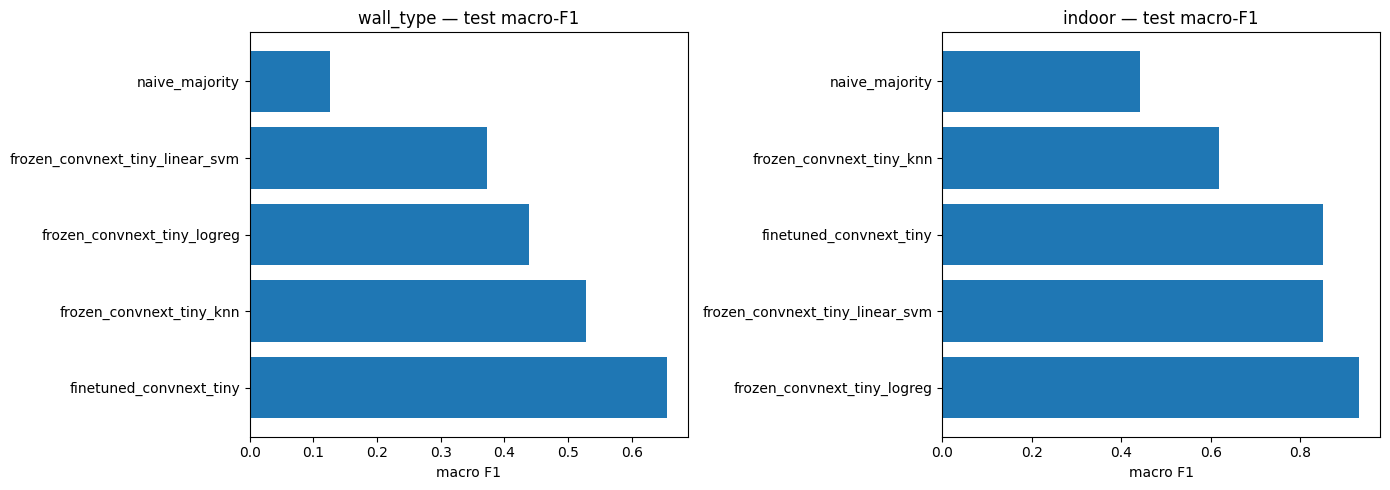

In [13]:
# ============================================================
# 9. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results).sort_values(["task", "macro_f1"], ascending=[True, False])
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"convnext_{CONVNEXT_VARIANT}_baseline_results.csv"), index=False)
display(results_df)

fig, axes = plt.subplots(1, len(TASKS), figsize=(7 * len(TASKS), 5))
for ax, task in zip(axes, TASKS):
    sub = results_df[results_df["task"] == task]
    ax.barh(sub["method"], sub["macro_f1"])
    ax.set_title(f"{task} — test macro-F1")
    ax.set_xlabel("macro F1")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, f"convnext_{CONVNEXT_VARIANT}_comparison.png"), dpi=150)
plt.show()


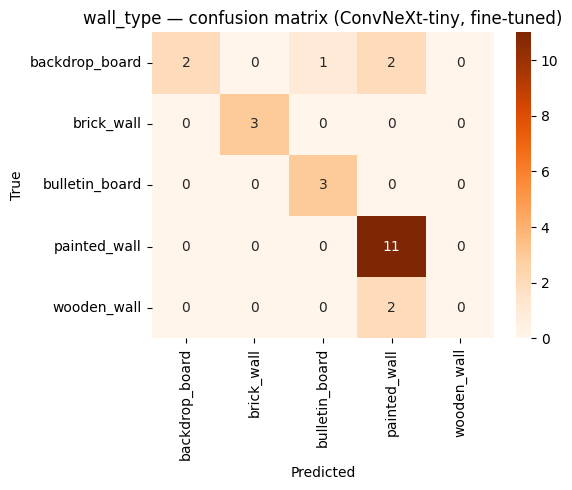


wall_type classification report (ConvNeXt-tiny, fine-tuned):
                precision    recall  f1-score   support

backdrop_board       1.00      0.40      0.57         5
    brick_wall       1.00      1.00      1.00         3
bulletin_board       0.75      1.00      0.86         3
  painted_wall       0.73      1.00      0.85        11
   wooden_wall       0.00      0.00      0.00         2

      accuracy                           0.79        24
     macro avg       0.70      0.68      0.65        24
  weighted avg       0.76      0.79      0.74        24



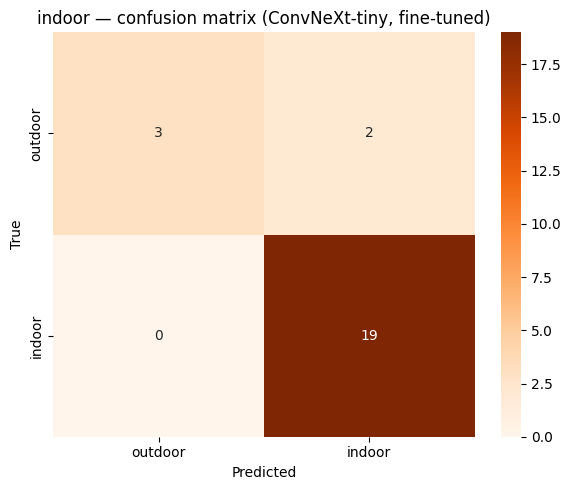


indoor classification report (ConvNeXt-tiny, fine-tuned):
              precision    recall  f1-score   support

     outdoor       1.00      0.60      0.75         5
      indoor       0.90      1.00      0.95        19

    accuracy                           0.92        24
   macro avg       0.95      0.80      0.85        24
weighted avg       0.92      0.92      0.91        24



In [14]:
# ============================================================
# 10. CONFUSION MATRIX FOR THE FINE-TUNED MODEL, PER TASK
# ============================================================

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    model = finetuned_models[task]
    test_ds = WallDecorationDataset(test_df, target_column, transform=eval_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(DEVICE))
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    labels_display = WALL_TYPE_CLASSES if task == "wall_type" else ["outdoor", "indoor"]
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_display, yticklabels=labels_display, cmap="Oranges")
    plt.title(f"{task} — confusion matrix (ConvNeXt-{CONVNEXT_VARIANT}, fine-tuned)")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, f"convnext_{CONVNEXT_VARIANT}_confusion_matrix_{task}.png"), dpi=150)
    plt.show()

    print(f"\n{task} classification report (ConvNeXt-{CONVNEXT_VARIANT}, fine-tuned):")
    print(classification_report(all_labels, all_preds, target_names=[str(l) for l in labels_display], zero_division=0))


## GroupKFold cross-validation (recommended second number to report)

In [15]:
# ============================================================
# 11. GROUP K-FOLD CROSS-VALIDATION
# ============================================================

N_FOLDS = 5
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

cv_results = []
for task in TASKS:
    if task == "wall_type":
        full_encoder = LabelEncoder().fit(full_df["wall_type"])
        full_df["wall_type_label"] = full_encoder.transform(full_df["wall_type"])
        target_column = "wall_type_label"
    else:
        target_column = "indoor"

    X_all, y_all = extract_features(convnext_extractor, full_df, target_column, BATCH_SIZE)
    groups = full_df["group_id"].values

    n_splits = min(N_FOLDS, pd.Series(groups).nunique())
    gkf = GroupKFold(n_splits=n_splits)
    fold_f1s = []
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups), start=1):
        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
        clf.fit(X_all[tr_idx], y_all[tr_idx])
        y_pred = clf.predict(X_all[te_idx])
        f1_macro = f1_score(y_all[te_idx], y_pred, average="macro", zero_division=0)
        fold_f1s.append(f1_macro)
        print(f"[{task}] fold {fold}/{n_splits} macro_f1={f1_macro:.3f}")

    cv_results.append({"task": task, "method": f"frozen_convnext_{CONVNEXT_VARIANT}_logreg_groupkfold",
                        "mean_macro_f1": np.mean(fold_f1s), "std_macro_f1": np.std(fold_f1s)})
    print(f"[{task}] {n_splits}-fold mean macro_f1 = {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}\n")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"convnext_{CONVNEXT_VARIANT}_groupkfold_results.csv"), index=False)
display(cv_results_df)


[wall_type] fold 1/5 macro_f1=0.538
[wall_type] fold 2/5 macro_f1=0.629
[wall_type] fold 3/5 macro_f1=0.517
[wall_type] fold 4/5 macro_f1=0.553
[wall_type] fold 5/5 macro_f1=0.478
[wall_type] 5-fold mean macro_f1 = 0.543 ± 0.050

[indoor] fold 1/5 macro_f1=0.793
[indoor] fold 2/5 macro_f1=0.688
[indoor] fold 3/5 macro_f1=0.890
[indoor] fold 4/5 macro_f1=0.851
[indoor] fold 5/5 macro_f1=0.724
[indoor] 5-fold mean macro_f1 = 0.789 ± 0.076



,task,method,mean_macro_f1,std_macro_f1
0,wall_type,frozen_convnext_tiny_logreg_groupkfold,0.542908,0.050023
1,indoor,frozen_convnext_tiny_logreg_groupkfold,0.789165,0.075558
